# Lab 3 Quantum Measurements

Prerequisite
- [Ch.1.4 Single Qubit Gates](/course/ch-states/single-qubit-gates)
- [Ch.2.2 Multiple Qubits and Entangled States](/course/ch-gates/multiple-qubits-and-entangled-states)
- [Mitigating Noise on Real Quantum Computers](https://www.youtube.com/watch?v=yuDxHJOKsVA&list=PLOFEBzvs-Vvp2xg9-POLJhQwtVktlYGbY&index=8)

Other relevant materials
- [Feynman Lectures Ch. III - 12](https://www.feynmanlectures.caltech.edu/III_12.html)
- [Quantum Operation](https://qiskit.org/documentation/tutorials/circuits/3_summary_of_quantum_operations.html)
- [Interactive Bloch Sphere](https://nonhermitian.org/kaleido/stubs/kaleidoscope.interactive.bloch_sphere.html#kaleidoscope.interactive.bloch_sphere)
- [Ch.5.2 Measurement Error Mitigation](/course/quantum-hardware/measurement-error-mitigation)

In [4]:
from qiskit import *
import numpy as np
from numpy import linalg as la
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import Aer, AerSimulator
from qiskit.visualization import plot_histogram
from qiskit.quantum_info import Statevector
import numpy as np
from numpy import linalg as la

## Part 1: Measuring the state of a qubit


**Goal**

Determine the Bloch components of a qubit.

Fundamental to the operation of a quantum computer is the ability to compute the Bloch components of a qubit or qubits.  These components correspond to the expectation values of the Pauli operators $X, Y, Z$, and are important quantities for applications such as quantum chemistry and optimization.  Unfortunately, it is impossible to simultaneously compute these values, thus requiring many executions of the same circuit.  In addition, measurements are restricted to the computational basis (Z-basis) so that each Pauli needs to be rotated to the standard basis to access the x and y components.  Here we verify the methods by considering the case of a random vector on the Bloch sphere.

### &#128211; 1. Express the expectation values of the Pauli operators for an arbitrary qubit state $|q\rangle$ in the computational basis.

The case for the expectation value of Pauli Z gate is given as an example. 

Using the diagonal representation, also known as spectral form or orthonormal decomposition, of Pauli $Z$ gate and the relations among the Pauli gates (see [here](/course/ch-states/single-qubit-gates)), expectation values of $ X, Y, Z $ gates can be written as  

$$
\begin{aligned}
\langle Z \rangle &=\langle q | Z | q\rangle =\langle q|0\rangle\langle 0|q\rangle - \langle q|1\rangle\langle 1|q\rangle
=|\langle 0 |q\rangle|^2 - |\langle 1 | q\rangle|^2\\\\
\langle X \rangle &= \\\\
\langle Y \rangle &=
\end{aligned}
\\
$$
, respectively.

Therefore, the expectation values of the Paulis for a qubit state $|q\rangle$ can be obtained by making a measurement in the standard basis after rotating the standard basis frame to lie along the corresponding axis. The probabilities of obtaining the two possible outcomes 0 and 1 are used to evaluate the desired expectation value as the above equations show.

### 2. Measure the Bloch sphere coordinates of a qubit using the qasm simulator and plot the vector on the bloch sphere.

#### &#128211;Step A. Create a qubit state using the circuit method, <code>initialize</code> with two random complex numbers as the parameter.

To learn how to use the function `initialize`, check [here](https://qiskit.org/documentation/tutorials/circuits/3_summary_of_quantum_operations.html). ( go to the `arbitrary initialization` section. )

Initial state coefficients:
alpha (amplitude of |0⟩): (0.26901890032600173+0.6828644098840152j)
beta (amplitude of |1⟩): (0.5257653195535269+0.4299951833868864j)
Verification - |alpha|^2 + |beta|^2 = 1.0

Initial Circuit:
   ┌────────────────────────────────────────────┐
q: ┤ Initialize(0.26902+0.68286j,0.52577+0.43j) ├
   └────────────────────────────────────────────┘

Theoretical Bloch sphere representation:


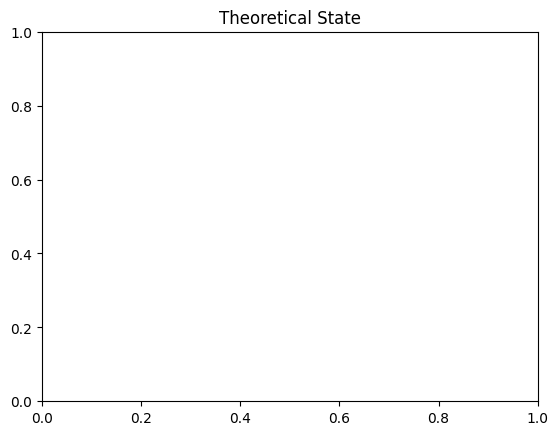

In [5]:
from matplotlib import pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram, plot_bloch_multivector
from qiskit.quantum_info import Statevector
import numpy as np

qc = QuantumCircuit(1)
# Step A: Create a qubit state with random complex numbers
np.random.seed(42)  # For reproducibility, remove for true randomness

# Generate two random complex numbers
alpha = np.random.rand() + 1j * np.random.rand()
beta = np.random.rand() + 1j * np.random.rand()

# Normalize to ensure |alpha|^2 + |beta|^2 = 1
norm = np.sqrt(np.abs(alpha)**2 + np.abs(beta)**2)
alpha = alpha / norm
beta = beta / norm

print(f"Initial state coefficients:")
print(f"alpha (amplitude of |0⟩): {alpha}")
print(f"beta (amplitude of |1⟩): {beta}")
print(f"Verification - |alpha|^2 + |beta|^2 = {np.abs(alpha)**2 + np.abs(beta)**2}")

# Create quantum circuit and initialize the state
qc = QuantumCircuit(1)
qc.initialize([alpha, beta], 0)

# Visualize the initial circuit
print("\nInitial Circuit:")
print(qc.draw())

# Visualize the state on Bloch sphere (theoretical)
statevec = Statevector([alpha, beta])
print("\nTheoretical Bloch sphere representation:")
plot_bloch_multivector(statevec)
plt.title("Theoretical State")
plt.show()




#### &#128211;Step B. Build the circuits to measure the expectation values of $X, Y, Z$ gate based on your answers to the question 1.  Run the cell below to estimate the bloch sphere coordinates of the qubit from step A using the qasm simulator.

The circuit for $Z$ gate measurement is given as an example.


Z measurements:
Circuit measures qubit directly in computational (Z) basis
     ┌─┐
  q: ┤M├
     └╥┘
c: 1/═╩═
      0 
Results: {'0': 1000}

X measurements:
Hadamard gate rotates from X-basis to Z-basis before measurement
     ┌───┐┌─┐
  q: ┤ H ├┤M├
     └───┘└╥┘
c: 1/══════╩═
           0 
Results: {'1': 503, '0': 497}

Y measurements:

S† and Hadamard gates rotate from Y-basis to Z-basis before measurement
     ┌─────┐┌───┐┌─┐
  q: ┤ Sdg ├┤ H ├┤M├
     └─────┘└───┘└╥┘
c: 1/═════════════╩═
                  0 
Results: {'1': 492, '0': 508}
Counts: {'0': 15333, '1': 1051}
P(0) = 0.9359, P(1) = 0.0641
Expectation value = 0.8717

Counts: {'0': 4201, '1': 12183}
P(0) = 0.2564, P(1) = 0.7436
Expectation value = -0.4872

Counts: {'1': 7547, '0': 8837}
P(0) = 0.5394, P(1) = 0.4606
Expectation value = 0.0787

Measured Bloch sphere coordinates: [0.870, -0.486, 0.079]
Magnitude before normalization: 1.0017
Magnitude after normalization: 1.0000


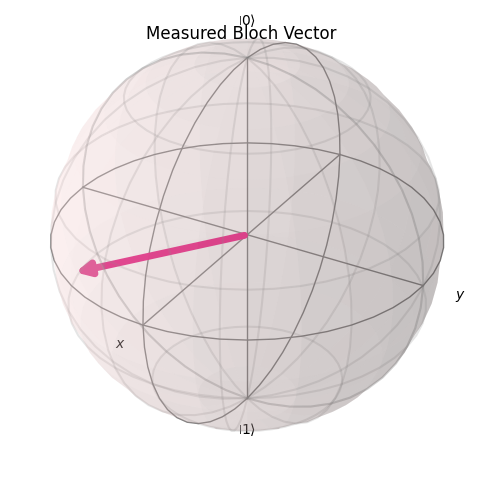


Theoretical Bloch coordinates: [0.870, -0.487, 0.077]
Difference from measured: [0.000, 0.000, 0.001]


In [6]:
# Initialize simulator
simulator = AerSimulator()

# z measurement of qubit 0
measure_z = QuantumCircuit(1,1)
measure_z.measure(0,0)
print('\nZ measurements:')
print('Circuit measures qubit directly in computational (Z) basis')
print(measure_z)
# Run Z measurement
compiled_z = transpile(measure_z, simulator)
result_z = simulator.run(compiled_z, shots=1000).result()
counts_z = result_z.get_counts()
print(f'Results: {counts_z}')


# x measurement of qubit 0
measure_x = QuantumCircuit(1,1)
# your code goes here
measure_x.h(0)  # Hadamard gate rotates X-basis to Z-basis
measure_x.measure(0, 0)
print('\nX measurements:')
print('Hadamard gate rotates from X-basis to Z-basis before measurement')
print(measure_x)

# Run X measurement
compiled_x = transpile(measure_x, simulator)
result_x = simulator.run(compiled_x, shots=1000).result()
counts_x = result_x.get_counts()
print(f'Results: {counts_x}')





# y measurement of qubit 0
measure_y = QuantumCircuit(1,1)
# your code goes here
measure_y.sdg(0)  # S† gate (phase rotation of -90°)
measure_y.h(0)    # Hadamard gate
measure_y.measure(0, 0)
print('\nY measurements:')
print('\nS† and Hadamard gates rotate from Y-basis to Z-basis before measurement')
print(measure_y)

# Run Y measurement
compiled_y = transpile(measure_y, simulator)
result_y = simulator.run(compiled_y, shots=1000).result()
counts_y = result_y.get_counts()
print(f'Results: {counts_y}')



shots = 2**14  # number of samples used for statistics
sim = Aer.get_backend('qasm_simulator')

bloch_vector_measure = []

for measure_circuit in [measure_x, measure_y, measure_z]:
    
    # Combine the initialization circuit with measurement circuit
    combined_circuit = qc.compose(measure_circuit)
    
    # Transpile and run the circuit
    transpiled_circuit = transpile(combined_circuit, sim)
    job = sim.run(transpiled_circuit, shots=shots)
    counts = job.result().get_counts()
    
    # calculate the probabilities for each bit value
    probs = {}
    for output in ['0', '1']:
        if output in counts:
            probs[output] = counts[output]/shots
        else:
            probs[output] = 0
    
    # Calculate expectation value: <Pauli> = P(0) - P(1)
    expectation = probs['0'] - probs['1']
    bloch_vector_measure.append(expectation)
    
    print(f"Counts: {counts}")
    print(f"P(0) = {probs['0']:.4f}, P(1) = {probs['1']:.4f}")
    print(f"Expectation value = {expectation:.4f}\n")

# Convert to numpy array
bloch_vector_measure = np.array(bloch_vector_measure)

# normalizing the bloch sphere vector
bloch_vector = bloch_vector_measure / la.norm(bloch_vector_measure)

print('='*50)
print('Measured Bloch sphere coordinates: [{0:4.3f}, {1:4.3f}, {2:4.3f}]'
    .format(*bloch_vector))
print(f'Magnitude before normalization: {la.norm(bloch_vector_measure):.4f}')
print(f'Magnitude after normalization: {la.norm(bloch_vector):.4f}')
print('='*50)

# Optional: Visualize on Bloch sphere
from qiskit.visualization import plot_bloch_vector
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='3d')
plot_bloch_vector(bloch_vector, ax=ax)
plt.title('Measured Bloch Vector')
plt.show()

# Compare with theoretical values
pauli_x = np.array([[0, 1], [1, 0]])
pauli_y = np.array([[0, -1j], [1j, 0]])
pauli_z = np.array([[1, 0], [0, -1]])

state = np.array([alpha, beta])

exp_x_theory = np.real(np.conj(state) @ pauli_x @ state)
exp_y_theory = np.real(np.conj(state) @ pauli_y @ state)
exp_z_theory = np.real(np.conj(state) @ pauli_z @ state)

theoretical_bloch = np.array([exp_x_theory, exp_y_theory, exp_z_theory])
theoretical_bloch_normalized = theoretical_bloch / la.norm(theoretical_bloch)

print('\nTheoretical Bloch coordinates: [{0:4.3f}, {1:4.3f}, {2:4.3f}]'
    .format(*theoretical_bloch_normalized))
print('Difference from measured: [{0:4.3f}, {1:4.3f}, {2:4.3f}]'
    .format(*(bloch_vector - theoretical_bloch_normalized)))





# shots = 2**14 # number of samples used for statistics
# sim = Aer.get_backend('qasm_simulator')
# bloch_vector_measure = []
# for measure_circuit in [measure_x, measure_y, measure_z]:
    
#     # run the circuit with a the selected measurement and get the number of samples that output each bit value
#     counts = execute(qc+measure_circuit, sim, shots=shots).result().get_counts()

#     # calculate the probabilities for each bit value
#     probs = {}
#     for output in ['0','1']:
#         if output in counts:
#             probs[output] = counts[output]/shots
#         else:
#             probs[output] = 0
            
#     bloch_vector_measure.append( probs['0'] -  probs['1'] )

# # normalizing the bloch sphere vector
# bloch_vector = bloch_vector_measure/la.norm(bloch_vector_measure)

# print('The bloch sphere coordinates are [{0:4.3f}, {1:4.3f}, {2:4.3f}]'
#     .format(*bloch_vector))    

Step B : Understanding 
Bloch Vector Measurement Documentation
Purpose
Measures a quantum state in three different bases (X, Y, Z) to determine its position on the Bloch sphere.
How It Works
1. Measurement Circuits

Z-basis: Direct measurement → measures |0⟩ vs |1⟩
X-basis: Apply Hadamard, then measure → measures |+⟩ vs |−⟩
Y-basis: Apply S†, then Hadamard, then measure → measures |+i⟩ vs |−i⟩

**S-dagger** (S†), which is the adjoint (inverse) of the S gate.
Quick Explanation

S gate: Applies a +90° phase rotation around the Z-axis

Matrix: [[1, 0], [0, i]]


**S† (sdg)**: Applies a -90° phase rotation around the Z-axis

Matrix: [[1, 0], [0, -i]]

To measure in the Y-basis, you need to rotate the Y eigenstates to align with the Z-basis:
|+i⟩ and |-i⟩ (Y eigenstates) → |0⟩ and |1⟩ (Z eigenstates)
The transformation is:

**S† gate**: Rotates the phase by -90°
Hadamard gate: Completes the basis change
Measure: Now measures in the original Y-basis


2. Data Collection
shots = 2^14 = 16,384 measurements per circuit

Combines initialization circuit qc with each measurement circuit
Runs on simulator and collects counts of '0' and '1' outcomes

3. Expectation Value Calculation
For each basis:
P(0) = (count of '0') / shots
P(1) = (count of '1') / shots
Expectation = P(0) - P(1)
This gives values between -1 and +1 representing the measurement outcome.
4. Bloch Vector Construction

X coordinate: Expectation value from X measurement
Y coordinate: Expectation value from Y measurement
Z coordinate: Expectation value from Z measurement
Normalization: Divides by vector magnitude to get unit vector

5. Verification
Compares measured Bloch coordinates with theoretical values calculated from:

State vector: [alpha, beta]
Pauli matrices: X, Y, Z
Formula: ⟨Pauli⟩ = ⟨ψ|Pauli|ψ⟩

Output

Measured Bloch coordinates [x, y, z]
Magnitude before/after normalization
Visual representation on Bloch sphere
Comparison with theoretical predictions
Difference between measured and theoretical values

Key Insight
By measuring in three orthogonal bases, you can reconstruct the complete quantum state's position on the Bloch sphere through quantum state tomography.

Aer simulator : 



#### Step C. Plot the vector on the bloch sphere.

Note that the following cell for the interactive bloch_sphere would not run properly unless you work in [IQX](https://quantum-computing.ibm.com/login). You can either use `plot_bloch_vector` for the non-interactive version or install `kaleidoscope` by running 

```
pip install kaleidoscope

```
in a terminal.  You also need to restart your kernel after the installation.  To learn more about how to use the interactive bloch sphere, go [here](https://nonhermitian.org/kaleido/stubs/kaleidoscope.interactive.bloch_sphere.html#kaleidoscope.interactive.bloch_sphere).

In [7]:
from kaleidoscope.interactive import bloch_sphere
from qiskit.visualization import plot_bloch_multivector
from qiskit.quantum_info import Statevector

bloch_sphere(bloch_vector, vectors_annotation=True)

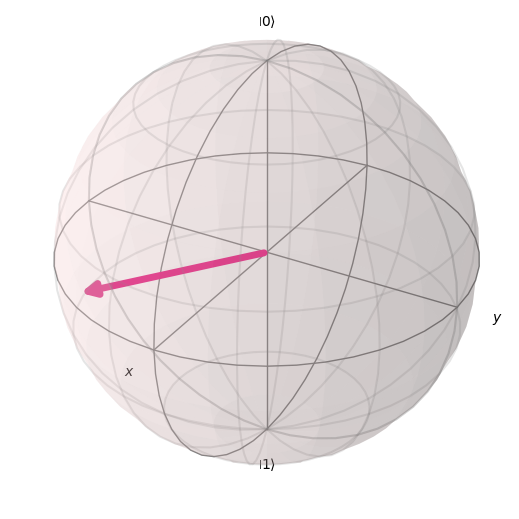

In [8]:
from qiskit.visualization import plot_bloch_vector

plot_bloch_vector( bloch_vector )

## Part 2: Measuring Energy


**Goal**

Evaluate the energy levels of the hydrogen ground state using qasm simulator.


The energy of a quantum system can be estimated by measuring the expectation value of its hamiltonian, which is a hermitian operator, through the procedure we mastered in part 1.

The ground state of hydrogen is not defined as a single unique state but actually contains four different states due to the spins of the electron and proton. In part 2 of this lab, we evaluate the energy difference among these four states, which is from the `hyperfine splitting`, by computing the energy expectation value for the system of two spins with the hamiltonian expressed in Pauli operators. For more information about `hyperfine structure`, see [here](https://www.feynmanlectures.caltech.edu/III_12.html)

Consider the system with two qubit interaction hamiltonian $H = A(XX+YY+ZZ)$ where $A = 1.47e^{-6} eV$ and $X, Y, Z$ are Pauli gates. Then the energy expectation value of the system can be evaluated by combining the expectation value of each term in the hamiltonian.
In this case, $E = \langle H\rangle = A( \langle XX\rangle + \langle YY\rangle + \langle ZZ\rangle )$. 

### &#128211; 1. Express the expectation value of each term in the hamiltonian for an arbitrary two qubit state   $|\psi \rangle$ in the computational basis.

The case for the term $\langle ZZ\rangle$ is given as an example.

$$
\begin{aligned}
\langle ZZ\rangle &=\langle \psi | ZZ | \psi\rangle =\langle \psi|(|0\rangle\langle 0| - |1\rangle\langle 1|)\otimes(|0\rangle\langle 0| - |1\rangle\langle 1|) |\psi\rangle
=|\langle 00|\psi\rangle|^2 - |\langle 01 | \psi\rangle|^2 - |\langle 10 | \psi\rangle|^2 + |\langle 11|\psi\rangle|^2\\\\
\langle XX\rangle &= \\\\
\langle YY\rangle &=
\end{aligned}
$$

### 2. Measure the expected energy of the system using the qasm simulator when two qubits are entangled. Regard the bell basis, four different entangled states.

#### &#128211;Step A. Construct the circuits to prepare four different bell states.

Let's label each bell state as,
$$
\begin{aligned}
Tri1 &= \frac{1}{\sqrt2} (|00\rangle + |11\rangle)\\
Tri2 &= \frac{1}{\sqrt2} (|00\rangle - |11\rangle)\\
Tri3 &= \frac{1}{\sqrt2} (|01\rangle + |10\rangle)\\
Sing &= \frac{1}{\sqrt2} (|10\rangle - |01\rangle)
\end{aligned}
$$

In [9]:
# circuit for the state Tri1 -> 1/√2 (|00⟩ + |11⟩)
Tri1 = QuantumCircuit(2)
# your code goes here
Tri1.h(0)      # Apply Hadamard to qubit 0
Tri1.cx(0, 1)  # Apply CNOT with control=0, target=1



# circuit for the state Tri2 -> 1/√2 (|00⟩ - |11⟩)

Tri2 = QuantumCircuit(2)
# your code goes here
Tri2.h(0)      # Apply Hadamard to qubit 0
Tri2.z(0)      # Apply Z gate to qubit 0 (adds phase)
Tri2.cx(0, 1)  # Apply CNOT with control=0, target=1




# circuit for the state Tri3 -> 1/√2 (|01⟩ + |10⟩)
Tri3 = QuantumCircuit(2)
# your code goes here
Tri3.h(0)      # Apply Hadamard to qubit 0
Tri3.x(1)      # Apply X gate to qubit 1
Tri3.cx(0, 1)  # Apply CNOT with control=0, target=1



# circuit for the state Sing ->  1/√2 (|10⟩ - |01⟩)
Sing = QuantumCircuit(2)
# your code goes here
Sing.h(0)      # Apply Hadamard to qubit 0
Sing.cx(0, 1)  # Apply CNOT with control=0, target=1
Sing.x(0)      # Apply X gate to qubit 0 - swap first bit 
Sing.z(1)      # Apply Z gate to qubit 1 - Introduces minus sign to |01>



'''
Explaination: 
Tri1: Standard Bell state - Hadamard on q0 creates superposition, CNOT entangles
Tri2: Similar to Tri1 but with Z gate to introduce minus sign
Tri3: X gate flips qubit 1 before entanglement to swap the basis states
Sing: Combination of X and Z gates to create the singlet state with correct phase
'''



'\nExplaination: \nTri1: Standard Bell state - Hadamard on q0 creates superposition, CNOT entangles\nTri2: Similar to Tri1 but with Z gate to introduce minus sign\nTri3: X gate flips qubit 1 before entanglement to swap the basis states\nSing: Combination of X and Z gates to create the singlet state with correct phase\n'

#### &#128211;Step B. Create the circuits to measure the expectation value of each term in the hamiltonian based on your answer to the question 1.

In [10]:
# <ZZ> 
measure_ZZ = QuantumCircuit(2)
measure_ZZ.measure_all()

# <XX>
measure_XX = QuantumCircuit(2)
# <XX> - rotate from X basis to Z basis using Hadamard
measure_XX.h(0)  # Rotate qubit 0 from X to Z basis
measure_XX.h(1)  # Rotate qubit 1 from X to Z basis
measure_XX.measure_all()





# <YY>
measure_YY = QuantumCircuit(2)
# <YY> - rotate from Y basis to Z basis using S†H
measure_YY.sdg(0)  # Apply S† (inverse of S gate) to qubit 0
measure_YY.h(0)    # Apply Hadamard to qubit 0
measure_YY.sdg(1)  # Apply S† to qubit 1
measure_YY.h(1)    # Apply Hadamard to qubit 1
measure_YY.measure_all()

'''
Explaination:
Basis Rotations:

Z basis: No rotation needed (computational basis)
X basis → Z basis: Apply H gate (since H|+⟩ = |0⟩ and H|-⟩ = |1⟩)
Y basis → Z basis: Apply S†H gates (since S†H rotates |+i⟩ → |0⟩ and |-i⟩ → |1⟩)


'''




'\nExplaination:\nBasis Rotations:\n\nZ basis: No rotation needed (computational basis)\nX basis → Z basis: Apply H gate (since H|+⟩ = |0⟩ and H|-⟩ = |1⟩)\nY basis → Z basis: Apply S†H gates (since S†H rotates |+i⟩ → |0⟩ and |-i⟩ → |1⟩)\n\n\n'

#### Step C. Execute the circuits on qasm simulator by runnng the cell below and evaluate the energy expectation value for each state.

In [16]:

#### Step C. Execute the circuits on qasm simulator by runnng the cell below and evaluate the energy expectation value for each state.
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
import numpy as np
# Initialize the simulator
sim = AerSimulator()
shots = 2**14 # number of samples used for statistics
A = 1.47e-6 #unit of A is eV
E_sim = []
for state_init in [Tri1,Tri2,Tri3,Sing]:
    Energy_meas = []
    for measure_circuit in [measure_XX, measure_YY, measure_ZZ]:
    
        # run the circuit with a the selected measurement and get the number of samples that output each bit value
        circuit = state_init.compose(measure_circuit)
        qc = transpile(circuit, sim)
        job = simulator.run(qc,shots=shots)
        result = job.result()
        counts = result.get_counts()

        # Calculate the probabilities for each computational basis
        probs = {}
        for output in ['00','01', '10', '11']:
            if output in counts:
                probs[output] = counts[output]/shots
            else:
                probs[output] = 0
            
        Energy_meas.append( probs['00'] - probs['01'] - probs['10'] + probs['11'] )
 
    E_sim.append(A * np.sum(np.array(Energy_meas)))


In [12]:
# Run this cell to print out your results

print('Energy expection value of the state Tri1 : {:.3e} eV'.format(E_sim[0]))
print('Energy expection value of the state Tri2 : {:.3e} eV'.format(E_sim[1]))
print('Energy expection value of the state Tri3 : {:.3e} eV'.format(E_sim[2]))
print('Energy expection value of the state Sing : {:.3e} eV'.format(E_sim[3]))

Energy expection value of the state Tri1 : 1.470e-06 eV
Energy expection value of the state Tri2 : 1.470e-06 eV
Energy expection value of the state Tri3 : 1.470e-06 eV
Energy expection value of the state Sing : -4.410e-06 eV


#### Step D. Understanding the result.

If you found the energy expectation values successfully, you would have obtained exactly the same value, $A (= 1.47e^{-6} eV)$, for the trplet tates, $|Tri1\rangle, |Tri2\rangle, |Tri3\rangle$ and one lower energy level, $-3A (= -4.41e^{-6} eV)$ for the singlet state $|Sing\rangle$.   

What we have done here is measuring the energies of the four different spin states corresponding to the ground state of hydrogen and observed `hyperfine structure` in the energy levels caused by spin-spin coupling.  This tiny energy difference between the singlet and triplet states is the reason for the famous 21-cm wavelength radiation used to map the structure of the galaxy.  

In the cell below, we varify the wavelength of the emission from the transition between the triplet states and singlet state. 

In [13]:
# reduced plank constant in (eV) and the speed of light(cgs units)
hbar, c = 4.1357e-15, 3e10

# energy difference between the triplets and singlet
E_del = abs(E_sim[0] - E_sim[3])

# frequency associated with the energy difference
f = E_del/hbar

# convert frequency to wavelength in (cm) 
wavelength = c/f

print('The wavelength of the radiation from the transition\
in the hyperfine structure is : {:.1f} cm'.format(wavelength))

The wavelength of the radiation from the transitionin the hyperfine structure is : 21.1 cm


## Part 3: Execute the circuits on Quantum Computer


**Goal**

Re-run the circuits on a IBM quantum system.  Perform measurement error mitigations on the result to improve the accuracy in the energy estimation.


#### Step A. Run the following cells to load your account and select the backend

In [14]:
provider = IBMQ.load_account()

NameError: name 'IBMQ' is not defined

In [ ]:
backend = provider.get_backend('ibmq_athens')

#### Step B. Execute the circuits on the quantum system.


In Lab1 when we excuted multiple circuits on a real quantum system, we submitted each circuit as a sperate job which produces the multiple job ids.  This time, we put all the circuits in a list and execute the list of the circuits as one job. In this way, all the circuit execution can happen at once, which would possibly decrease your wait time in the queue.

In addition, `transpile` is not used here as all the circuits that we run consist of one or two qubit gates.  We can still specify the initial_layout and optimization_level through `execute` function.  Without using `transpile`, the transpiled circuits are not accessible which is not a concern for this case. 

&#128211; Check the backend configuration information and error map through the widget to determine your <code>initial_layout</code>.

In [ ]:
# run this cell to get the backend information through the widget
backend

In [ ]:
# assign your choice for the initial layout to the list variable `initial_layout`.
initial_layout = 

Run the following cell to execute the circuits with the initial_layout on the backend.

In [ ]:
qc_all = [state_init+measure_circuit for state_init in [Tri1,Tri2,Tri3,Sing] 
          for measure_circuit in [measure_XX, measure_YY, measure_ZZ] ]  

shots = 8192
job = execute(qc_all, backend, initial_layout=initial_layout, optimization_level=3, shots=shots)
print(job.job_id())
job_monitor(job)

In [19]:
# getting the results of your job
results = job.result()

In [20]:
## To access the results of the completed job
#results = backend.retrieve_job('job_id').result()

#### Step C. Estimate the ground state energy levels from the results of the previous step by executing the cells below.

In [21]:
def Energy(results, shots):
    """Compute the energy levels of the hydrogen ground state.
    
    Parameters:
        results (obj): results, results from executing the circuits for measuring a hamiltonian.
        shots (int): shots, number of shots used for the circuit execution.
        
    Returns:
        Energy (list): energy values of the four different hydrogen ground states
    """
    E = []
    A = 1.47e-6

    for ind_state in range(4):
        Energy_meas = []
        for ind_comp in range(3):
            counts = results.get_counts(ind_state*3+ind_comp)
        
            # calculate the probabilities for each computational basis
            probs = {}
            for output in ['00','01', '10', '11']:
                if output in counts:
                    probs[output] = counts[output]/shots
                else:
                    probs[output] = 0
            
            Energy_meas.append( probs['00'] - probs['01'] - probs['10'] + probs['11'] )

        E.append(A * np.sum(np.array(Energy_meas)))
    
    return E

In [22]:
E = Energy(results, shots)

print('Energy expection value of the state Tri1 : {:.3e} eV'.format(E[0]))
print('Energy expection value of the state Tri2 : {:.3e} eV'.format(E[1]))
print('Energy expection value of the state Tri3 : {:.3e} eV'.format(E[2]))
print('Energy expection value of the state Sing : {:.3e} eV'.format(E[3]))

QiskitError: 'Result for experiment "1" could not be found.'

In [ ]:
#Step C 

import numpy as np
from numpy import linalg as la
from kaleidoscope.interactive import bloch_sphere
from qiskit.visualization import plot_bloch_vector
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
#from qiskit.ignis.mitigation.measurement import *

#----Quantum Machine

from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit import transpile
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit_ibm_runtime import EstimatorV2 as Estimator

key = "7xTkDspNkuH74fwEqyEPchHhX6yHb6C9QP8r4GNwPooK"
QiskitRuntimeService.save_account(channel="ibm_quantum_platform", token=key, overwrite = True)

service = QiskitRuntimeService()

backend = service.least_busy(operational=True, simulator=False)
print(backend.name)


#circuit

#Part A

##circuit for the state Tri1
Tri1 = QuantumCircuit(2) #00

Tri1.h(0)
Tri1.cx(0,1)

#circuit for the state Tri2
Tri2 = QuantumCircuit(2) #10

Tri2.x(0)
Tri2.h(0)
Tri2.cx(0,1)

#circuit for the state Tri3
Tri3 = QuantumCircuit(2) #01

Tri3.h(0)      # Apply Hadamard to qubit 0
Tri3.x(1)      # Apply X gate to qubit 1
Tri3.cx(0, 1)  # Apply CNOT with control=0, target=1


#circuit for the state Sing
Sing = QuantumCircuit(2) #11

Sing.x(0)
Sing.h(0)
Sing.x(1)
Sing.cx(0,1)

#Part B
#<ZZ>
measure_ZZ = QuantumCircuit(2)
measure_ZZ.measure_all()

#<XX>
measure_XX = QuantumCircuit(2)

measure_XX.h(0)
measure_XX.h(1)
measure_XX.measure_all()

#<YY>
measure_YY = QuantumCircuit(2)
measure_YY.sdg(0)
measure_YY.h(0)

measure_YY.sdg(1)
measure_YY.h(1)
measure_YY.measure_all()
#circuit
simulator = AerSimulator()

shots = 8192 # number of samples used for statistics

qc_all = [state_init.compose(measure_circuit) for state_init in [Tri1,Tri2,Tri3,Sing] 
            for measure_circuit in [measure_XX, measure_YY, measure_ZZ] ]


qc_all_transpiled = transpile(qc_all, backend=backend, optimization_level=3)

#Run using SamplerV2
sampler = Sampler(mode=backend)

#Correct syntax for SamplerV2 - pass list of circuits directly
job = sampler.run(qc_all_transpiled, shots=8192)

#Get results
result = job.result()

def Energy(results, shots):

  """Compute the energy levels of the hydrogen ground state.

    Parameters:
        results: PrimitiveResult from SamplerV2
        shots (int): number of shots used

    Returns:
        Energy (list): energy values of the four different hydrogen ground states
  """
  E = []
  A = 1.47e-6

  for ind_state in range(4):
      Energy_meas = []
      for ind_comp in range(3):
          idx = ind_state * 3 + ind_comp

#Get counts from SamplerV2 result
          pub_result = result[idx]
          counts_dict = pub_result.data.meas.get_counts()

#Calculate probabilities
          probs = {}
          for output in ['00', '01', '10', '11']:
              if output in counts_dict:
                  probs[output] = counts_dict[output] / shots
              else:
                  probs[output] = 0

          Energy_meas.append(probs['00'] - probs['01'] - probs['10'] + probs['11'])

      E.append(A * np.sum(np.array(Energy_meas)))

  return E

E = Energy(result, shots)

print('Energy expection value of the state Tri1 : {:.3e} eV'.format(E[0]))
print('Energy expection value of the state Tri2 : {:.3e} eV'.format(E[1]))
print('Energy expection value of the state Tri3 : {:.3e} eV'.format(E[2]))
print('Energy expection value of the state Sing : {:.3e} eV'.format(E[3]))

management.get:WARNING:2025-11-10 15:32:57,930: Loading default saved account
qiskit_runtime_service.__init__:WARNING:2025-11-10 15:33:00,149: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2025-11-10 15:33:00,497: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2025-11-10 15:33:02,149: Using instance: open-instance, plan: open


ibm_torino
Energy expection value of the state Tri1 : 1.413e-06 eV
Energy expection value of the state Tri2 : 1.403e-06 eV
Energy expection value of the state Tri3 : 1.411e-06 eV
Energy expection value of the state Sing : -4.229e-06 eV


#### Step D. Measurement error mitigation.

The results you obtained from running the circuits on the quantum system are not exact due to the noise from the various sources such as enery relaxation, dephasing, crosstalk between qubits, etc. In this step, we will alleviate the effects of the noise through the measurement error mitigation. Before we start, watch this [video](https://www.youtube.com/watch?v=yuDxHJOKsVA&list=PLOFEBzvs-Vvp2xg9-POLJhQwtVktlYGbY&index=8). 

In [ ]:
from qiskit.ignis.mitigation.measurement import *

&#128211;Construct the circuits to profile the measurement errors of all basis states using the function 'complete_meas_cal'.  Obtain the measurement filter object, 'meas_filter', which will be applied to the noisy results to mitigate readout (measurement) error. 

For further helpful information to complete this task, check [here](/course/quantum-hardware/measurement-error-mitigation) . 

In [ ]:
# your code to create the circuits, meas_calibs, goes here
meas_calibs, state_labels = 



# execute meas_calibs on your choice of the backend
job = execute(meas_calibs, backend, shots = shots)
print(job.job_id())
job_monitor(job)
cal_results = job.result()
## To access the results of the completed job
#cal_results = backend.retrieve_job('job_id').result()


# your code to obtain the measurement filter object, 'meas_filter', goes here






In [ ]:
results_new = meas_filter.apply(results)

In [ ]:
E_new = Energy(results_new, shots)

print('Energy expection value of the state Tri1 : {:.3e} eV'.format(E_new[0]))
print('Energy expection value of the state Tri2 : {:.3e} eV'.format(E_new[1]))
print('Energy expection value of the state Tri3 : {:.3e} eV'.format(E_new[2]))
print('Energy expection value of the state Sing : {:.3e} eV'.format(E_new[3]))

#### Step E. Interpret the result.

&#128211; Compute the relative errors ( or the fractional error ) of the energy values for all four states with and without measurement error mitigation.

In [ ]:
# results for the energy estimation from the simulation, 
# execution on a quantum system without error mitigation and
# with error mitigation in numpy array format 
Energy_exact, Energy_exp_orig, Energy_exp_new = np.array(E_sim), np.array(E), np.array(E_new)

In [ ]:
# Calculate the relative errors of the energy values without error mitigation 
# and assign to the numpy array variable `Err_rel_orig` of size 4
Err_rel_orig =

In [ ]:
# Calculate the relative errors of the energy values with error mitigation 
# and assign to the numpy array variable `Err_rel_new` of size 4
Err_rel_new = 

In [ ]:
np.set_printoptions(precision=3)

print('The relative errors of the energy values for four bell basis\
 without measurement error mitigation : {}'.format(Err_rel_orig))

In [ ]:
np.set_printoptions(precision=3)

print('The relative errors of the energy values for four bell basis\
 with measurement error mitigation : {}'.format(Err_rel_new))

&#128211; Compare the size of the errors before and after the measurment error mitigation and discuss about the effect of the readout error regarding the error map information of the backend that you selected.  

**Your answer:**